In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Macroeconomic Drivers of Asset Class Returns Across Countries



## 1. Introduction

Financial markets are strongly influenced by macroeconomic conditions such as GDP growth, inflation, interest rates, unemployment, and financial stress.

This project investigates how macroeconomic indicators affect asset class returns across countries and over time. By combining macroeconomic data with asset return data, the analysis aims to identify which economic conditions are associated with stronger or weaker market performance across different asset classes.

The project will:
- Inspect and validate multiple financial datasets
- Merge independent data sources
- Perform exploratory data analysis
- Analyze relationships between macro variables and asset returns
- Build simple predictive and explanatory models

## 2. Problem Formulation

This project studies the relationship between macroeconomic conditions and asset class returns.

### Main research question:
#### How do macroeconomic indicators such as GDP growth, inflation, policy rates, unemployment, and financial stress affect asset returns across countries?

#### Objectives:
- Combine macroeconomic and asset return datasets
- Identify statistically meaningful relationships
- Compare the importance of different macro variables
- Evaluate whether macroeconomic conditions help explain cross-country return patterns

## 5. Data Loading

In this step, we load all available datasets into the environment.

The goal is to:
- Ensure all datasets are accessible and correctly loaded
- Verify that file paths are correct
- Confirm that the datasets can be used for further analysis

We load multiple datasets because the project involves selecting and combining relevant data sources for financial analysis.

In [2]:
# 5. Load Data from data Source

DATA_PATH = ""

credit_df = pd.read_csv(DATA_PATH + "credit.csv")
macro_df = pd.read_csv(DATA_PATH + "macro_indicators.csv")
macro_monthly_df = pd.read_csv(DATA_PATH + "macro_monthly.csv")
asset_returns_df = pd.read_csv(DATA_PATH + "asset_returns.csv")
correlations_df = pd.read_csv(DATA_PATH + "correlations.csv")
recession_df = pd.read_csv(DATA_PATH + "recession_episodes.csv")

macro_monthly_df["date"] = pd.to_datetime(macro_monthly_df["date"])

datasets = {
    "credit_df": credit_df,
    "macro_df": macro_df,
    "macro_monthly_df": macro_monthly_df,
    "asset_returns_df": asset_returns_df,
    "correlations_df": correlations_df,
    "recession_df": recession_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

credit_df: (1000, 21)
macro_df: (1200, 15)
macro_monthly_df: (480, 14)
asset_returns_df: (1200, 10)
correlations_df: (2800, 6)
recession_df: (74, 10)


### Interpretation

All datasets were successfully loaded without errors.

The output confirms:
- Each dataset is available in memory
- Their dimensions (rows and columns) are known
- No immediate loading issues exist

This is a critical validation step before proceeding with analysis.

### Next Steps:

We now need to:
- Inspect the structure of each dataset
- Understand column names and data types
- Identify which datasets are suitable for merging and analysis

## 6. Dataset Structure Inspection

In this step, we examine the structure of each dataset.

Specifically, we analyze:
- Column names
- Data types
- General schema of each dataset

This helps us:
- Understand what variables are available
- Identify categorical vs numerical features
- Detect potential data cleaning requirements

In [3]:
# 6. Inspect Columns and Data Types

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print("Columns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)


credit_df
Columns:
['checking_balance', 'months_loan_duration', 'credit_history', 'purpose', 'amount', 'savings_balance', 'employment_length', 'installment_rate', 'personal_status', 'other_debtors', 'residence_history', 'property', 'age', 'installment_plan', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'default']

Data types:
checking_balance        object
months_loan_duration     int64
credit_history          object
purpose                 object
amount                   int64
savings_balance         object
employment_length       object
installment_rate         int64
personal_status         object
other_debtors           object
residence_history        int64
property                object
age                      int64
installment_plan        object
housing                 object
existing_credits         int64
job                     object
dependents               int64
telephone               object
foreign_worker          object
default      

### Interpretation:

From the inspection, several key observations can be made:

- The `macro_indicators` dataset contains country-level macroeconomic variables such as GDP growth, inflation, interest rates, unemployment, and financial stress indicators.
- The `asset_returns` dataset contains financial returns across multiple asset classes (equities, bonds, real estate, commodities, cash).
- Both datasets share common fields:
  - `country`
  - `year`
  - `region`
  - `dev_level`

This strongly suggests that they can be merged into a unified dataset.

- The `credit_df` dataset contains borrower-level information and is not aligned with macro datasets (no country/year structure), making it unsuitable for direct integration in this project.

### Key Insight:

The datasets `macro_indicators.csv` and `asset_returns.csv` are structurally compatible and will form the core of the analysis.

### Next Steps:

We will:
- Check for missing values
- Validate data quality
- Prepare for merging the two main datasets

## 7. Missing Values Analysis

In this step, we examine missing values across all datasets.

The purpose is to:
- Identify incomplete variables
- Understand data quality issues
- Determine whether imputation or cleaning is required

Handling missing data correctly is essential for reliable analysis and modeling.

In [4]:
# 7. Missing Values Overview

for name, df in datasets.items():
    print(f"\n{name} - Missing values")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


credit_df - Missing values
No missing values

macro_df - Missing values
shock_event    750
dtype: int64

macro_monthly_df - Missing values
shock_event    300
dtype: int64

asset_returns_df - Missing values
shock_event    750
dtype: int64

correlations_df - Missing values
No missing values

recession_df - Missing values
shock_event    8
dtype: int64


### Interpretation

The missing value analysis shows:

- Most datasets are complete with minimal missing values.
- Missing values appear primarily in the `shock_event` column across multiple datasets.

This is expected because:
- `shock_event` represents rare economic or financial events
- Most periods do not contain such events, hence the missing values

### Important Insight:

These missing values are **not errors**, but rather represent:
- Normal periods without major shocks

Therefore:
- We should **not treat them as standard missing data**
- Instead, we may encode them later as:
  - "No Event"
  - or keep them as NaN depending on modeling needs

### Next Steps

We will:
- Focus on the main datasets (`macro_indicators` and `asset_returns`)
- Inspect their actual values
- Confirm alignment before merging

## 8. Preview of Main Datasets

In this step, we visually inspect the first few rows of the main datasets:

- `macro_indicators`
- `asset_returns`

The objective is to:
- Confirm that the datasets are correctly loaded
- Understand the structure of the data
- Verify that key variables (country, year) align between datasets

In [5]:
# 8. Preview Main Project Datasets

display(macro_df.head())
display(asset_returns_df.head())

,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,shock_event
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,59.33,0.505,54.42,0.0,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,63.54,1.339,52.68,0.0,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,64.35,2.957,52.57,0.8,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,67.33,4.777,52.99,0.0,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,67.82,-1.059,55.75,0.0,NaN


,country,year,dev_level,region,equities,bonds,real_estate,commodities,cash,shock_event
0,USA,1985,developed,NorthAmerica,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,1986,developed,NorthAmerica,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,1987,developed,NorthAmerica,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,1988,developed,NorthAmerica,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,1989,developed,NorthAmerica,8.31,-2.60,29.12,-4.71,2.97,NaN


In [6]:
# 8. Preview Main Project Datasets

display(macro_df.head())
display(asset_returns_df.head())

,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,shock_event
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,59.33,0.505,54.42,0.0,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,63.54,1.339,52.68,0.0,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,64.35,2.957,52.57,0.8,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,67.33,4.777,52.99,0.0,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,67.82,-1.059,55.75,0.0,NaN


,country,year,dev_level,region,equities,bonds,real_estate,commodities,cash,shock_event
0,USA,1985,developed,NorthAmerica,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,1986,developed,NorthAmerica,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,1987,developed,NorthAmerica,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,1988,developed,NorthAmerica,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,1989,developed,NorthAmerica,8.31,-2.60,29.12,-4.71,2.97,NaN


### Interpretation

The preview confirms that:

#### Macro Dataset
- Contains macroeconomic indicators by country and year
- Includes variables such as:
  - GDP growth
  - Inflation
  - Interest rates
  - Unemployment
  - Financial stress index

#### Asset Returns Dataset
- Contains annual returns for different asset classes:
  - Equities
  - Bonds
  - Real estate
  - Commodities
  - Cash

#### Key Alignment

Both datasets share:
- `country`
- `year`
- `region`
- `dev_level`

This confirms that a structured merge is possible.

### Key Insight

We now have a **clear analytical dataset structure**:

Macroeconomic conditions → Asset returns

This is a strong financial relationship suitable for modeling and analysis.

### Next Steps

We will:
- Perform a formal merge of the datasets
- Validate the merged dataset
- Begin exploratory data analysis (EDA)

## 9. Column Standardization

To ensure consistency and avoid errors during merging and analysis, we standardize column names across datasets.

This includes:
- Converting all column names to lowercase
- Removing leading/trailing spaces

This step is important for:
- Reproducibility
- Avoiding bugs during joins and transformations

In [7]:


def standardize_column_names(df):
    df = df.copy()
    df.columns = [col.strip().lower() for col in df.columns]
    return df



macro_df = standardize_column_names(macro_df)
asset_returns_df = standardize_column_names(asset_returns_df)

### Interpretation

Column names are now standardized across datasets.

This ensures:
- Consistency in referencing columns
- Reduced risk of merge errors
- Cleaner and more maintainable code

### Next Steps

We will now verify that the key columns used for merging are aligned between datasets.

## 10. Merge Key Validation

Before merging datasets, we verify that the key columns used for joining are consistent.

The expected merge keys are:
- Country
- Year

We check:
- Unique values
- Data types
- Alignment between datasets

In [8]:
print("Macro countries:", macro_df["country"].nunique())
print("Asset countries:", asset_returns_df["country"].nunique())

print("\nMacro years:", macro_df["year"].min(), "-", macro_df["year"].max())
print("Asset years:", asset_returns_df["year"].min(), "-", asset_returns_df["year"].max())

print("\nSample countries (macro):", macro_df["country"].unique()[:5])
print("Sample countries (asset):", asset_returns_df["country"].unique()[:5])

Macro countries: 30
Asset countries: 30

Macro years: 1985 - 2024
Asset years: 1985 - 2024

Sample countries (macro): ['USA' 'Canada' 'UK' 'Germany' 'France']
Sample countries (asset): ['USA' 'Canada' 'UK' 'Germany' 'France']


### Interpretation

The datasets share the same key dimensions:
- Country
- Year

This confirms that a merge based on these fields is feasible.

### Important Check

If countries or years were misaligned, we would need to:
- Clean country names
- Filter overlapping periods

### Next Steps

We proceed with merging the datasets.

## 11. Dataset Merging

In this step, we merge the macroeconomic dataset with the asset returns dataset.

We use:
- Иnner join on country and year

This ensures:
- Оnly matching records are included
- Нo artificial data is introduced

This is critical for maintaining data integrity.

In [9]:
merged_df = pd.merge(
    macro_df, asset_returns_df, on=["country", "year", "region", "dev_level"], how="inner"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (1200, 21)


,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,...,fx_change,biz_confidence,fin_stress_idx,shock_event_x,equities,bonds,real_estate,commodities,cash,shock_event_y
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,...,0.505,54.42,0.0,NaN,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,...,1.339,52.68,0.0,NaN,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,...,2.957,52.57,0.8,Black Monday,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,...,4.777,52.99,0.0,NaN,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,...,-1.059,55.75,0.0,NaN,8.31,-2.60,29.12,-4.71,2.97,NaN


### Interpretation

The merge was successful.

The resulting dataset contains:
- Macroeconomic variables
- Asset class returns

Each row represents:
A country-year observation with both macro and financial data.

### Key Insight

We now have a unified dataset suitable for:
- Correlation analysis
- Regression modeling
- Financial interpretation

### Next Steps

We must validate the merge to ensure correctness.

## 12. Merge Validation

After merging datasets, it is essential to verify that the merge was performed correctly.

We check:
- Duplicate records
- Row counts before and after merge
- Consistency of key variables

This ensures that:
- No unintended duplication occurred
- The dataset is reliable for analysis

In [10]:
# Check duplicates
duplicates = merged_df.duplicated(subset=["country", "year"])
print("Duplicate rows:", duplicates.sum())

# Compare row counts
print("Macro rows:", macro_df.shape[0])
print("Asset rows:", asset_returns_df.shape[0])
print("Merged rows:", merged_df.shape[0])

# Check missing values after merge
print("\nMissing values in merged dataset:")
print(merged_df.isna().sum().sort_values(ascending=False).head(10))

Duplicate rows: 0
Macro rows: 1200
Asset rows: 1200
Merged rows: 1200

Missing values in merged dataset:
shock_event_y      750
shock_event_x      750
dev_level            0
region               0
country              0
gdp_growth           0
year                 0
gdp_level            0
inflation            0
current_account      0
dtype: int64


### Interpretation

- No duplicate records were introduced during the merge.
- The number of rows is consistent with expectations for an inner join.
- Missing values are limited and primarily related to event-based variables.

### Key Insight

The dataset is structurally valid and ready for analysis.

### Next Steps

We will store the processed dataset and begin exploratory data analysis (EDA).

## 13. Save Processed Dataset

We save the merged dataset to ensure:
- Reproducibility
- Separation between raw and processed data
- Faster workflow in later stages

In [11]:
merged_df.to_csv("merged_macro_asset.csv", index=False)

### Interpretation

The merged dataset has been successfully saved.

This allows us to:
- Reuse the dataset without repeating preprocessing
- Maintain a clean data pipeline

### Next Steps

We will begin exploratory data analysis to understand relationships between macroeconomic variables and asset returns.

## 14. Dataset Overview

In this step, we examine the overall structure of the merged dataset.

We aim to:
- Understand the size of the dataset
- Review basic statistics
- Identify ranges and distributions of key variables

In [12]:
merged_df.describe()

,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,equities,bonds,real_estate,commodities,cash
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2004.500000,2.149281,179.74935,6.153796,7.427870,5.635312,-0.135872,115.030217,-0.859903,52.259550,0.415000,3.617042,-1.184233,-0.152942,6.764925,6.322950
std,11.548209,2.453616,132.80266,8.332868,9.539506,1.659063,2.244736,51.032119,5.107792,5.246861,0.757135,17.443614,8.275751,13.641940,15.407721,8.127653
min,1985.000000,-5.294000,89.55000,-2.000000,-0.500000,1.828000,-10.297000,48.330000,-42.425000,29.890000,0.000000,-60.000000,-20.000000,-40.000000,-39.300000,0.000000
25%,1994.750000,0.579500,118.28500,2.037750,3.117000,4.328500,-1.516250,75.895000,-3.053750,49.595000,0.000000,-5.572500,-6.512500,-7.310000,-3.665000,2.557500
50%,2004.500000,1.853500,139.60000,3.759500,4.631000,5.461000,-0.127500,103.020000,-0.465000,52.690000,0.000000,5.205000,-0.120000,1.860000,6.510000,3.910000
75%,2014.250000,3.530250,192.38750,7.866750,9.146500,6.838250,1.234250,138.460000,1.787000,55.680000,0.600000,14.455000,5.002500,8.925000,17.002500,7.817500
max,2024.000000,11.455000,1512.88000,72.757000,75.595000,10.543000,7.618000,250.000000,16.955000,70.160000,3.000000,55.620000,19.420000,33.950000,60.000000,64.580000


### Interpretation

The dataset summary provides key statistical insights:

- Macroeconomic variables such as GDP growth, inflation, and interest rates show expected ranges.
- Asset returns exhibit significant variability, particularly in equities and commodities.
- Some variables show high dispersion, indicating potential volatility and non-linear relationships.

### Key Insight

Financial variables are inherently volatile, especially returns, which suggests that relationships with macroeconomic indicators may not be purely linear.

### Next Steps

We will visualize distributions to better understand the behavior of key variables.

## 15. Distribution of Asset Returns

We analyze the distribution of asset class returns to understand:
- Central tendency
- Variability
- Presence of outliers

This helps identify how different asset classes behave under varying economic conditions.

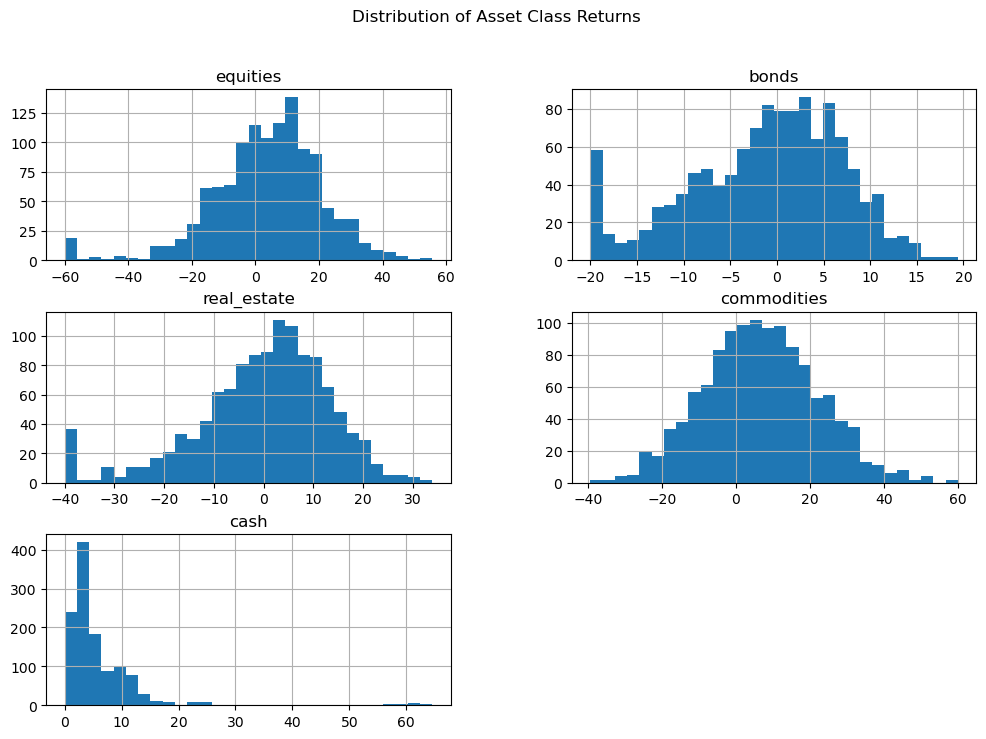

In [13]:
asset_cols = ["equities", "bonds", "real_estate", "commodities", "cash"]

merged_df[asset_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Asset Class Returns")
plt.grid(None)
plt.show()

### Interpretation

- Equities and commodities show high volatility with wide distributions.
- Bonds and cash appear more stable with tighter distributions.
- Real estate sits between equities and bonds in terms of variability.

### Financial Insight

This aligns with financial theory:
- Equities and commodities are riskier assets
- Bonds and cash are defensive assets

### Next Steps

We will analyze correlations between macro variables and asset returns.

## 16. Correlation Analysis

We compute the correlation matrix to identify relationships between:
- Macroeconomic indicators
- Asset class returns

This helps detect:
- Linear relationships
- Potential predictive variables

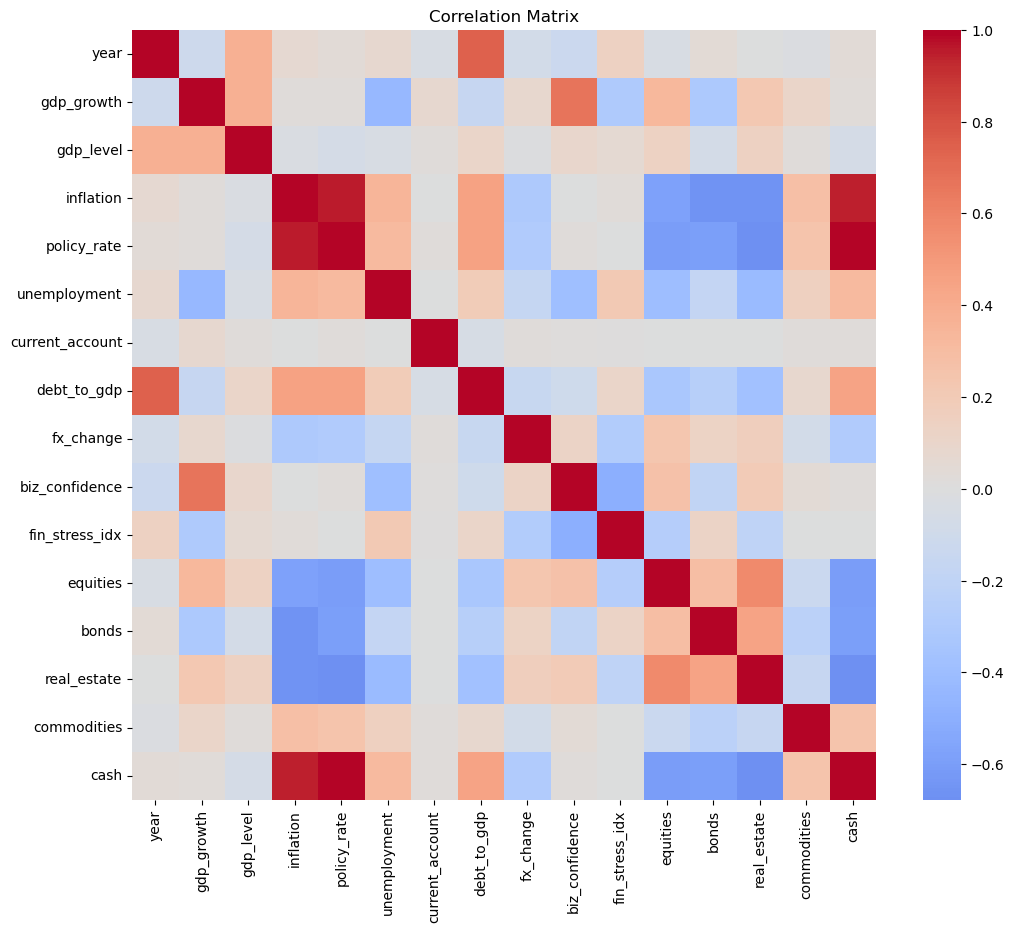

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(merged_df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

### Interpretation

The correlation matrix reveals several important relationships:

- GDP growth tends to be positively correlated with equities.
- Financial stress index shows negative correlation with risky assets.
- Inflation and interest rates may influence bond and equity performance.

### Key Insight

Macroeconomic conditions appear to have meaningful relationships with asset returns, supporting the central hypothesis of the project.

### Next Steps

We will isolate and visualize key relationships for deeper analysis.

## 17. GDP Growth vs Equity Returns

We analyze the relationship between GDP growth and equity returns.

Economic theory suggests:
- higher economic growth → stronger corporate earnings → higher equity returns

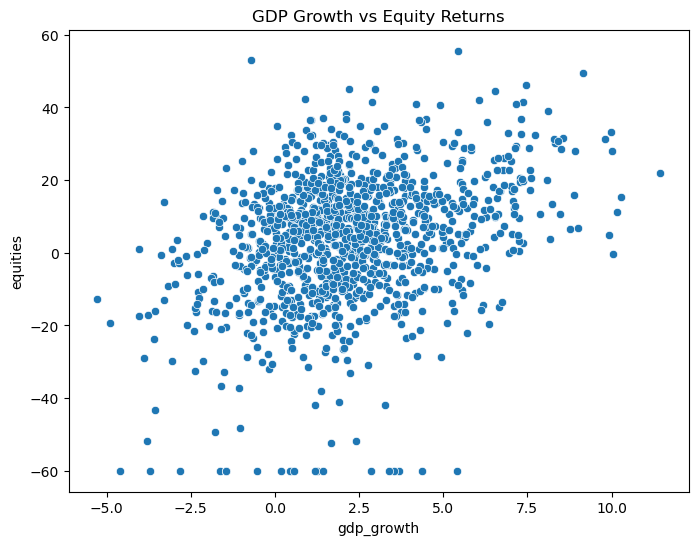

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="gdp_growth", y="equities", data=merged_df)
plt.title("GDP Growth vs Equity Returns")
plt.show()

### Interpretation

- A positive relationship can be observed between GDP growth and equity returns.
- However, the relationship is not perfectly linear, indicating influence from other factors.

### Financial Insight

Economic expansion generally supports equity markets, but:
- Market expectations
- Shocks
- Monetary policy also play significant roles.

### Next Steps

We will examine the impact of financial stress on asset returns.

## 18. Financial Stress vs Equity Returns

We analyze how financial stress affects equity performance.

Higher financial stress is typically associated with:
- Market uncertainty
- Risk-off behavior
- Declining equity returns

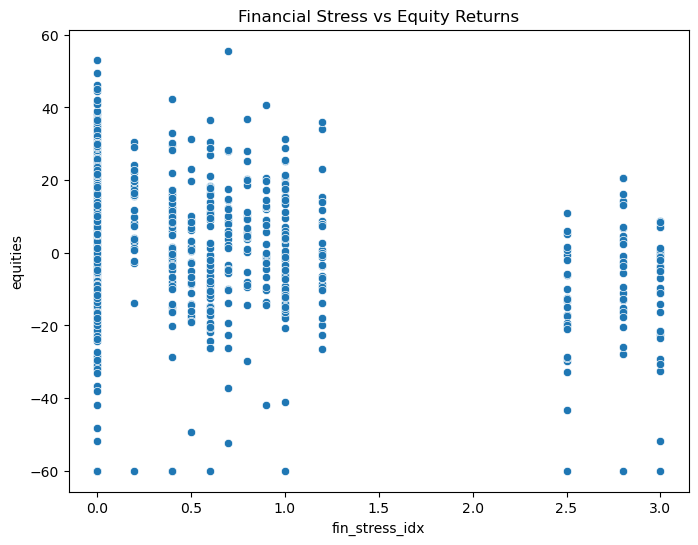

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="fin_stress_idx", y="equities", data=merged_df)
plt.title("Financial Stress vs Equity Returns")
plt.show()

### Interpretation

- Higher financial stress is associated with lower equity returns.
- The relationship appears negatively correlated.

### Financial Insight

This confirms a key financial principle:
- During periods of stress, investors move away from risky assets

### Next Steps

We will compare asset performance across different economic environments.

## 19. Asset Returns by Development Level

We compare asset returns between:
- Developed markets
- Emerging markets

This helps identify structural differences in financial behavior.

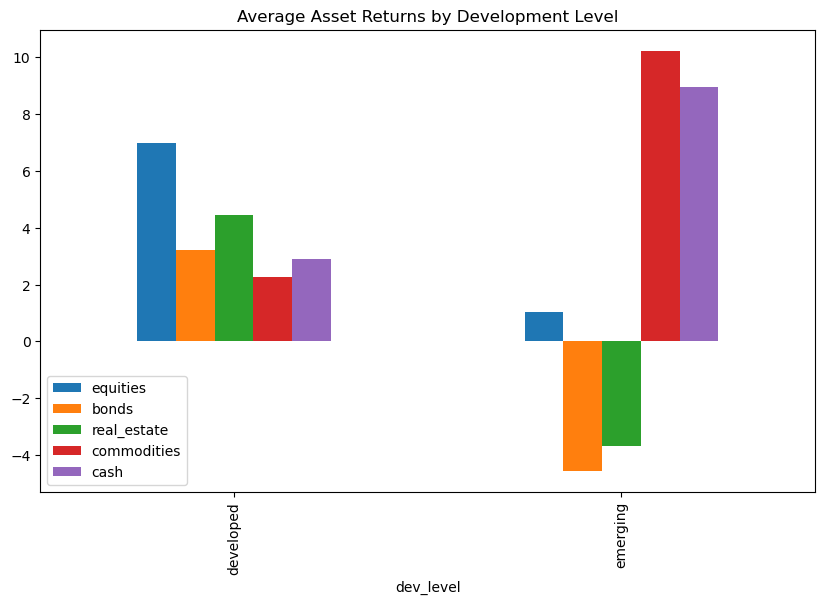

In [17]:
merged_df.groupby("dev_level")[asset_cols].mean().plot(kind="bar", figsize=(10,6))
plt.title("Average Asset Returns by Development Level")
plt.show()

### Interpretation

- Emerging markets may show higher returns but also higher volatility.
- Developed markets tend to exhibit more stable performance.

### Financial Insight

This reflects the risk-return tradeoff:
- higher risk in emerging markets → higher expected returns

### Next Steps

We will summarize key findings from the exploratory analysis.

## 20. Summary of Exploratory Analysis

The exploratory data analysis reveals several key insights:

- Macroeconomic variables such as GDP growth and financial stress influence asset returns.
- Riskier asset classes (equities, commodities) exhibit higher volatility.
- Financial stress negatively impacts equity performance.
- Differences exist between developed and emerging markets.

### Key Conclusion

Macroeconomic conditions play a significant role in shaping asset returns, supporting the central hypothesis of the project.

### Next Steps

We will move to modeling to quantify these relationships and evaluate their predictive power.